In [1]:
# libraries
import requests
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import time
import matplotlib.colors as mcolors
import astropy.units as u
import pandas as pd
import sympy as sp

from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.cosmology import FlatLambdaCDM
from pysr import PySRRegressor
from scipy.stats import binned_statistic_dd
from sklearn.metrics import mean_squared_error, median_absolute_error
from scipy.optimize import curve_fit
from sklearn.mixture import GaussianMixture
from scipy.stats import norm


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
# get function
baseURL = 'http://www.tng-project.org/api/'
headers = {"api-key": "96ec8ab7a20d9b1666d6f0a5a4a8e0b9"}

def get(path, local_filename=None, params=None, max_retries=5):
    if local_filename and os.path.exists(local_filename):
        print(f"File {local_filename} already exists. Skipping network request.")
        return local_filename

    # ensure we use full URL pathways if just the API endpoint stub was provided
    url = path if path.startswith('http') else baseURL + path

    for attempt in range(max_retries):
        try:
            r = requests.get(url, params=params, headers=headers, stream=True)
            r.raise_for_status()

            if 'application/json' in r.headers.get('content-type', ''):
                return r.json()

            if not local_filename:
                if 'content-disposition' in r.headers:
                    local_filename = r.headers['content-disposition'].split("filename=")[1]
                else:
                    local_filename = url.split('/')[-1] if url.split('/')[-1] else 'downloaded_tng_file'

            if os.path.exists(local_filename):
                print(f"File {local_filename} derived from header already exists. Skipping save.")
                return local_filename

            # disk stream download routine with live visual readout
            total_size = int(r.headers.get('content-length', 0))
            block_size = 1024 * 1024  # 1 Megabyte chunks
            
            if total_size > 0:
                print(f"Downloading {local_filename} ({total_size / (1024**3):.2f} GB)...")
            else:
                print(f"Downloading {local_filename} (Unknown total file size)...")

            with open(local_filename, 'wb') as f:
                dl = 0
                start_time = time.time()
                for chunk in r.iter_content(chunk_size=block_size):
                    if chunk:
                        f.write(chunk)
                        dl += len(chunk)
                        
                        # status bar tracker
                        if total_size > 0:
                            done = int(50 * dl / total_size)
                            percent = (dl / total_size) * 100
                            elapsed = time.time() - start_time
                            speed = (dl / elapsed) / (1024**2) if elapsed > 0 else 0
                            print(f"\r[{'=' * done}{' ' * (50-done)}] {percent:.1f}% ({speed:.1f} MB/s)", end="")
                        else:
                            print(f"\rDownloaded: {dl / (1024**2):.1f} MB...", end="")
            print("\nDownload Complete!")
            return local_filename

        except requests.exceptions.HTTPError as e:
            # check for standard server-side rate limits or transient auth failures
            if r.status_code == 403 and attempt < max_retries - 1:
                wait_time = 2 ** attempt 
                print(f"\nAttempt {attempt+1} hit 403. Retrying in {wait_time}s...")
                time.sleep(wait_time)
                continue
            else:
                raise e

Extract and Prepare Data

In [3]:
# old way of collecting data (not active)
# for i in range(6):
#     with h5py.File('tree_extended.' + str(i) + '.hdf5', 'r') as f:
#         # defining masks to use
#         snapnums = f['SnapNum'][:]
#         snap_99_mask = (snapnums == 99)
#         row_indices_99 = np.where(snap_99_mask)[0]
#         print(f"Total rows in this file: {len(snapnums)}")

#         sub_pos_99 = f['SubhaloPos'][:][snap_99_mask]
#         sub_stel_mass_99 = f['SubhaloMassType'][:,4][snap_99_mask]
#         halo_vir_mass_99 = f['Group_M_Crit200'][:][snap_99_mask]
#         relative_pos = sub_pos_99 - f['GroupPos'][:][snap_99_mask]
#         r_3d_mask = np.sqrt(relative_pos[:,0]**2 + relative_pos[:,1]**2 + relative_pos[:,2]**2)
#         vir_radius_mask = f['Group_R_Crit200'][:][snap_99_mask]

#         # remove boundary condition subhalos and compute final mask
#         final_mask = (
#             (sub_pos_99[:, 0] > buffer) & (sub_pos_99[:, 0] < (boxsize - buffer)) &
#             (sub_pos_99[:, 1] > buffer) & (sub_pos_99[:, 1] < (boxsize - buffer)) &
#             (sub_pos_99[:, 2] > buffer) & (sub_pos_99[:, 2] < (boxsize - buffer)) &
#             (sub_stel_mass_99[:] > 1e9/1e10 * 0.704) &
#             (halo_vir_mass_99 > 1e13/1e10 * 0.704) &
#             (r_3d_mask <= vir_radius_mask)
#         )

#         # final mask to use
#         row_indices_99 = row_indices_99[final_mask]
#         print(f"Num of rows of Snapshot 99 after masking: {len(row_indices_99)}")

#         # extracting all info using the mask
#         tree_data['subhalos'] = {}
#         grp_pos = f['GroupPos'][:][row_indices_99]
#         grp_vel = f['GroupVel'][:][row_indices_99]

#         pos_x = f['SubhaloPos'][row_indices_99,0] - grp_pos[:,0]
#         pos_y = f['SubhaloPos'][row_indices_99,1] - grp_pos[:,1]
#         pos_z = f['SubhaloPos'][row_indices_99,2] - grp_pos[:,2]

#         vel_x = f['SubhaloVel'][row_indices_99,0] - grp_vel[:,0]
#         vel_y = f['SubhaloVel'][row_indices_99,1] - grp_vel[:,1]
#         vel_z = f['SubhaloVel'][row_indices_99,2] - grp_vel[:,2]

#         dist_3d = np.sqrt(pos_x**2 + pos_y**2 + pos_z**2)
#         r_proj_xy = np.sqrt(pos_x**2 + pos_y**2)
#         r_proj_xz = np.sqrt(pos_x**2 + pos_z**2)
#         r_proj_yz = np.sqrt(pos_y**2 + pos_z**2)
#         r_200 = f['Group_R_Crit200'][:][row_indices_99]
#         vir_mass = f['Group_M_Crit200'][:][row_indices_99]

#         v_disp = 397.9 * (vir_mass / (1e4 * 0.6774**-1))**0.3214

#         # infall time section
#         file_infall_z = [0.0]*len(row_indices_99)

#         # create map id -> row index | THIS WILL HELP for multiple redshifts and files
#         all_subhalo_ids = f['SubhaloID'][:]
#         id_to_index = {sub_id: idx for idx, sub_id in enumerate(all_subhalo_ids)}

#         for j in range(len(row_indices_99)): # loop thru every subhalo from snapshot 99
#             current_row_idx = row_indices_99[j]
#             infall_redshift = np.nan
            
#             while current_row_idx != -1: # loops until progenitor is greater than 3*R_200
#                 prog_snap = f['SnapNum'][current_row_idx]

#                 prog_grp_pos = f['GroupPos'][current_row_idx]
#                 prog_sub_pos = f['SubhaloPos'][current_row_idx]

#                 prog_pos_x = prog_sub_pos[0] - prog_grp_pos[0]
#                 prog_pos_y = prog_sub_pos[1] - prog_grp_pos[1]
#                 prog_pos_z = prog_sub_pos[2] - prog_grp_pos[2]

#                 prog_3D_dist = np.sqrt(prog_pos_x**2 + prog_pos_y**2 + prog_pos_z**2)
#                 prog_r200 = f['Group_R_Crit200'][current_row_idx]

#                 current_redshift = snap[prog_snap]['redshift']

#                 if prog_r200 > 0 and (prog_3D_dist / prog_r200) > 3.0:
#                     infall_redshift = current_redshift
#                     break

#                 fpid = f['FirstProgenitorID'][current_row_idx] # restarts while with fpid instead

#                 if fpid != -1 and fpid in id_to_index: # convert fpid to row num for diff file nums
#                     current_row_idx = id_to_index[fpid]
#                 else:
#                     current_row_idx = -1
                

#             file_infall_z[j] = infall_redshift
#             if j % 500 == 0:
#                 print(f"{file_infall_z[j]} {j}")

#         # append all data from files 
#         all_z.append(f['SnapNum'][row_indices_99])
#         all_id.append(f['SubhaloID'][row_indices_99])
#         all_vir_mass.append(vir_mass)
#         all_stel_mass.append(f['SubhaloMassType'][:,4][row_indices_99])
#         all_norm_r_xy.append(r_proj_xy / r_200)
#         all_norm_r_xz.append(r_proj_xz / r_200)
#         all_norm_r_yz.append(r_proj_yz / r_200)
#         all_norm_v_z.append(vel_z / v_disp)
#         all_norm_v_y.append(vel_y / v_disp)
#         all_norm_v_x.append(vel_x / v_disp)
#         all_infall_z.append(file_infall_z)

# # combine all data
# tree_data['subhalos'] = {
#     'z': np.concatenate(all_z),
#     'id': np.concatenate(all_id),
#     'vir_mass': np.concatenate(all_vir_mass),
#     'stel_mass': np.concatenate(all_stel_mass),
#     'norm_r_xy': np.concatenate(all_norm_r_xy),
#     'norm_r_xz': np.concatenate(all_norm_r_xz),
#     'norm_r_yz': np.concatenate(all_norm_r_yz),
#     'norm_v_z': np.concatenate(all_norm_v_z),
#     'norm_v_y': np.concatenate(all_norm_v_y),
#     'norm_v_x': np.concatenate(all_norm_v_x),
#     'infall_z': np.concatenate(all_infall_z)
# }

In [ ]:
# load data from files
tree_data = {'subhalos': {}}
with h5py.File(r"C:\Users\rizkw\Documents\LCP Research\Project Files\Reproducing Florine's Work\TNG300_1_data.hdf5","r") as f:
    subhalos_grp = f['subhalos']
    for key in subhalos_grp.keys():
        tree_data['subhalos'][key] = subhalos_grp[key][()]

with h5py.File(r"C:\Users\rizkw\Documents\LCP Research\Project Files\Reproducing Florine's Work\TNG-Cluster_data.hdf5",'r') as f:
    subhalos_grp = f['subhalos']
    for key in subhalos_grp.keys():
        new_data = subhalos_grp[key][()]
        existing_data = tree_data['subhalos'][key]
        tree_data['subhalos'][key] = np.concatenate((existing_data, new_data), axis=0)


In [5]:
# calculating lookback time

# this defines the constants we use in flat lambda CDM
cosmology = FlatLambdaCDM(H0=67.74, Om0=0.3089, Ob0=0.0486)

lookback_infall3 = cosmology.lookback_time(tree_data['subhalos']['infall_z3']).value
lookback_infall1 = cosmology.lookback_time(tree_data['subhalos']['infall_z1']).value
lookback_sub = cosmology.lookback_time(tree_data['subhalos']['z']).value

tree_data['subhalos']['lookback_time3'] = lookback_infall3 - lookback_sub

tree_data['subhalos']['lookback_time1'] = lookback_infall1 - lookback_sub


c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\astropy\cosmology\_src\flrw\lambdacdm.py:496: RuntimeWarning: invalid value encountered in divide
  np.emath.sqrt((1 / self.Om0 - 1 + 0j) / (aszarr(z) + 1.0) ** 3)
c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_scimath_impl.py:120: RuntimeWarning: invalid value encountered in less
  if any(isreal(x) & (x < 0)):
c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_scimath_impl.py:238: RuntimeWarning: invalid value encountered in sqrt
  return nx.sqrt(x)
c:\Users\rizkw\AppData\Local\Programs\Python\Python313\Lib\site-packages\astropy\cosmology\_src\flrw\lambdacdm.py:495: RuntimeWarning: invalid value encountered in arcsinh
  arg = np.arcsinh(


In [6]:
# recalculate 3d radius to filter out for 1 r200
tree_data['subhalos']['norm_r_3d'] = np.sqrt((tree_data['subhalos']['norm_r_xy']**2 + tree_data['subhalos']['norm_r_xz']**2 
                                              + tree_data['subhalos']['norm_r_yz']**2) / 2)

In [7]:
# store data in separate dicts for redshifts
r_axis = {}
v_axis = {}
infall_axis3 = {}
infall_axis1 = {}
stel = {}
vir = {}
log10stel = {}
log10vir = {}
steps = {}
z_inf = {}
infall_axis1_clean = {}
r_axis_clean = {}
v_axis_clean = {}

snapshots = [99, 84, 78, 67, 59, 50]
for snapshot in snapshots:
    snapRmask = (tree_data['subhalos']['snap'] == snapshot) & (tree_data['subhalos']['norm_r_3d'] <= 1.0)
    r_axis[snapshot] = []
    v_axis[snapshot] = []
    infall_axis3[snapshot] = []
    infall_axis1[snapshot] = []
    stel[snapshot] = []
    vir[snapshot] = []
    log10stel[snapshot] = []
    log10vir[snapshot] = []
    steps[snapshot] = []
    z_inf[snapshot] = []

    r_axis[snapshot].append(tree_data['subhalos']['norm_r_xy'][snapRmask])
    r_axis[snapshot].append(tree_data['subhalos']['norm_r_xz'][snapRmask])
    r_axis[snapshot].append(tree_data['subhalos']['norm_r_yz'][snapRmask])
    v_axis[snapshot].append(tree_data['subhalos']['norm_v_z'][snapRmask])
    v_axis[snapshot].append(tree_data['subhalos']['norm_v_y'][snapRmask])
    v_axis[snapshot].append(tree_data['subhalos']['norm_v_x'][snapRmask])
    infall_axis3[snapshot].append(tree_data['subhalos']['lookback_time3'][snapRmask])
    infall_axis3[snapshot].append(tree_data['subhalos']['lookback_time3'][snapRmask])
    infall_axis3[snapshot].append(tree_data['subhalos']['lookback_time3'][snapRmask])
    infall_axis1[snapshot].append(tree_data['subhalos']['lookback_time1'][snapRmask])
    infall_axis1[snapshot].append(tree_data['subhalos']['lookback_time1'][snapRmask])
    infall_axis1[snapshot].append(tree_data['subhalos']['lookback_time1'][snapRmask])
    stel[snapshot].append(tree_data['subhalos']['stel_mass'][snapRmask] * 1e10/ 0.6774)
    stel[snapshot].append(tree_data['subhalos']['stel_mass'][snapRmask] * 1e10/ 0.6774)
    stel[snapshot].append(tree_data['subhalos']['stel_mass'][snapRmask] * 1e10/ 0.6774)
    vir[snapshot].append(tree_data['subhalos']['vir_mass'][snapRmask] * 1e10/ 0.6774)
    vir[snapshot].append(tree_data['subhalos']['vir_mass'][snapRmask] * 1e10/ 0.6774)
    vir[snapshot].append(tree_data['subhalos']['vir_mass'][snapRmask] * 1e10/ 0.6774)
    steps[snapshot].append(tree_data['subhalos']['step_counts3'][snapRmask])
    steps[snapshot].append(tree_data['subhalos']['step_counts3'][snapRmask])
    steps[snapshot].append(tree_data['subhalos']['step_counts3'][snapRmask])
    z_inf[snapshot].append(tree_data['subhalos']['infall_z3'][snapRmask])
    z_inf[snapshot].append(tree_data['subhalos']['infall_z3'][snapRmask])
    z_inf[snapshot].append(tree_data['subhalos']['infall_z3'][snapRmask])
    r_axis[snapshot] = np.concatenate(r_axis[snapshot])
    v_axis[snapshot] = np.concatenate(v_axis[snapshot])
    infall_axis3[snapshot] = np.concatenate(infall_axis3[snapshot])
    infall_axis1[snapshot] = np.concatenate(infall_axis1[snapshot])
    log10stel[snapshot] = np.log10(np.concatenate(stel[snapshot]))
    log10vir[snapshot] = np.log10(np.concatenate(vir[snapshot]))
    steps[snapshot] = np.concatenate(steps[snapshot])
    z_inf[snapshot] = np.concatenate(z_inf[snapshot])

    # filter nans
    valid = ~np.isnan(infall_axis1[snapshot])
    infall_axis1_clean[snapshot] = infall_axis1[snapshot][valid]
    r_axis_clean[snapshot] = r_axis[snapshot][valid]
    v_axis_clean[snapshot] = v_axis[snapshot][valid]

Binning the data (r<=1 only)

In [8]:
# ALL BINNING CODE
X_binned = {}
y_mean = {}
y_q1 = {}
y_med = {}
y_q3 = {}

for snapshot in snapshots:
    # prepare all raw inputs as a matrix with columns of each input
    X_raw = np.column_stack((r_axis[snapshot], np.abs(v_axis[snapshot]), log10stel[snapshot])) #, log10vir[snapshot]))
    y_raw = infall_axis1[snapshot]

    X_raw[np.isinf(X_raw)] = np.nan

    clean_rows = ~np.isnan(X_raw).any(axis=1) & ~np.isnan(y_raw)

    X_clean = X_raw[clean_rows]
    y_clean = y_raw[clean_rows]
    # create percentile bins

    r_edges = np.percentile(X_clean[:,0], np.linspace(0, 100, 12))
    v_edges = np.percentile(X_clean[:,1], np.linspace(0, 100, 12))
    m_edges = np.percentile(X_clean[:,2], np.linspace(0, 100, 9))
    # vir_edges = np.percentile(X_clean[:,3], np.linspace(0, 100, 5))

    quartile_bins = [r_edges, v_edges, m_edges] #, vir_edges]
    # sort data into bins

    # compute num of galaxies in each bin
    counts, _, _ = binned_statistic_dd(
        X_clean, values=None, statistic='count', bins=quartile_bins
    )

    # mask for only filled bins
    filled = np.where(counts > 0)
    Ngal_per = counts[filled]
    weights = np.log10(Ngal_per + 10)

    # extract mean features for grid size
    binned = []
    for i in range(X_clean.shape[1]):
        means, _, _ = binned_statistic_dd(X_clean, values=X_clean[:,i], statistic='mean', bins=quartile_bins)
        binned.append(means[filled])
    X_binned[snapshot] = np.column_stack(binned)

    mean_y, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic='mean', bins=quartile_bins)
    y_mean[snapshot] = mean_y[filled]

    q1_y_grid, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic=lambda x: np.percentile(x, 25), bins=quartile_bins)
    y_q1[snapshot] = q1_y_grid[filled]

    q2_y_grid, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic=lambda x: np.percentile(x, 50), bins=quartile_bins)
    y_med[snapshot] = q2_y_grid[filled]

    q3_y_grid, _, _ = binned_statistic_dd(X_clean, values=y_clean, statistic=lambda x: np.percentile(x, 75), bins=quartile_bins)
    y_q3[snapshot] = q3_y_grid[filled]

    print(f"Num of binned data points for PySR: {len(y_mean[snapshot])}")
    # mask for valid entries in bins
    mean_mask = ~np.isnan(y_mean[snapshot]) & (y_mean[snapshot] > 0)
    q1_mask = ~np.isnan(y_q1[snapshot]) & (y_q1[snapshot] > 0)
    med_mask = ~np.isnan(y_med[snapshot]) & (y_med[snapshot] > 0)
    q3_mask = ~np.isnan(y_q3[snapshot]) & (y_q3[snapshot] > 0)

    y_mean[snapshot] = y_mean[snapshot][mean_mask]
    y_q1[snapshot] = y_q1[snapshot][q1_mask]
    y_med[snapshot] = y_med[snapshot][med_mask]
    y_q3[snapshot] = y_q3[snapshot][q3_mask]

    # X_binned[snapshot][:,2] = X_binned[snapshot][:,2]-10
    # X_binned[snapshot][:,3] = X_binned[snapshot][:,3]-10

Num of binned data points for PySR: 968
Num of binned data points for PySR: 968
Num of binned data points for PySR: 968
Num of binned data points for PySR: 968
Num of binned data points for PySR: 968
Num of binned data points for PySR: 968


Fitting Data with PySR

In [9]:
model = PySRRegressor(
    #elementwise_loss="loss(x, y) = abs(x - y)",
    niterations=1000,
    binary_operators=["+", "-", "*", "/", "^"],
    #binary_operators=["+", "-", "*", "^"],
    #unary_operators=["exp", "sqrt", "square", "cos"],
    unary_operators=["exp", "sqrt", "square", 'log'],
    procs=4,
    maxsize=20,       # Limits the size of expressions
    #maxdepth=20,
    populations=25,
    model_selection="best",
    constraints={ 'exp':3, '^': (-1, 0)}
)

In [10]:
print(snapshots)

[99, 84, 78, 67, 59, 50]


In [11]:
# model.fit(X_binned[84], y_mean[84], weights=weights, variable_names=["r","v","logMstel"]) #, "logMvir"])

In [12]:
for idx in range(len(model.equations_)):
        complexity = model.equations_.iloc[idx]['complexity']

        eqn_sympy = model.sympy(idx)
        
        # round to 3 decimals
        clean_eqn = eqn_sympy.atoms(sp.Float)
        mapping = {num: round(float(num), 3) for num in clean_eqn}
        final_eqn = eqn_sympy.subs(mapping)

        print(f"{final_eqn}")

AttributeError: 'PySRRegressor' object has no attribute 'equations_'

In [13]:
noMvir = PySRRegressor.from_file(run_directory=r"C:\Users\rizkw\Documents\LCP Research\Project Files\Work at r200\outputs\noMvir")
noMvir_m10 = PySRRegressor.from_file(run_directory=r"C:\Users\rizkw\Documents\LCP Research\Project Files\Work at r200\outputs\noMvir_-10")
withMvir = PySRRegressor.from_file(run_directory=r"C:\Users\rizkw\Documents\LCP Research\Project Files\Work at r200\outputs\withMvir")
withMvir_m10 = PySRRegressor.from_file(run_directory=r"C:\Users\rizkw\Documents\LCP Research\Project Files\Work at r200\outputs\withMvir_-10")

model_names = ["noMvir", "noMvir_m10", "withMvir", "withMvir_m10"]
models = [noMvir, noMvir_m10, withMvir, withMvir_m10]

for i, model in enumerate(models):
    print("-" * 80)
    print(f"All discovered eqns for {model_names[i]}")
    print("-" * 80)
    for idx in range(len(model.equations_)):
        # complexity = model.equations_.iloc[idx]['complexity']

        eqn_sympy = model.sympy(idx)
        
        # round to 3 decimals
        clean_eqn = eqn_sympy.atoms(sp.Float)
        mapping = {num: round(float(num), 3) for num in clean_eqn}
        final_eqn = eqn_sympy.subs(mapping)

        print(f"{final_eqn}")

Attempting to load model from C:\Users\rizkw\Documents\LCP Research\Project Files\Work at r200\outputs\noMvir\checkpoint.pkl...
Attempting to load model from C:\Users\rizkw\Documents\LCP Research\Project Files\Work at r200\outputs\noMvir_-10\checkpoint.pkl...
Attempting to load model from C:\Users\rizkw\Documents\LCP Research\Project Files\Work at r200\outputs\withMvir\checkpoint.pkl...
Attempting to load model from C:\Users\rizkw\Documents\LCP Research\Project Files\Work at r200\outputs\withMvir_-10\checkpoint.pkl...


--------------------------------------------------------------------------------
All discovered eqns for noMvir
--------------------------------------------------------------------------------
3.83500000000000
4.232 - r
(2.354 - r)**2
3.749*sqrt(-log(r))
-v + 7.098*exp(-r)
-v + 3.724/(r + 0.44)
-6.977*sqrt(r) - v + 8.991
-v + (sqrt(r) - 4.065)**2 - 7.242
-7.026*sqrt(r) - sqrt(exp(v)) + 9.802
sqrt(r)*(r - 8.112) - sqrt(exp(v)) + 10.162
-7.046*sqrt(r) - sqrt(exp(v)) - log(logMstel) + 12.108
sqrt(r)*(-0.26*logMstel - 4.458) - sqrt(exp(v)) + 9.81
-6.757*sqrt(r) - sqrt(exp(v)) + 9.814
sqrt(r)*(-0.261*logMstel + r - 5.534) - sqrt(exp(v)) + 10.169
-2.713*r - 0.228*(v + 0.87)**2 - log(logMstel*r) + 6.951
-2.726*r - 0.228*(-v - 0.885)**2 - log(logMstel**2*r) + 9.258
-0.176*logMstel - 2.719*r - 0.603*v**(3/2) - log(r) + 6.21
-0.056*logMstel**2 + logMstel - 2.683*r - 0.599*v**(3/2) - log(r)
--------------------------------------------------------------------------------
All discovered eqns for no

In [14]:
snap78models = PySRRegressor.from_file(run_directory=r"C:\Users\rizkw\Documents\LCP Research\Project Files\Work at r200\outputs\snap78_withvir")

for i in range(len(snap78models.equations_)):
        # complexity = model.equations_.iloc[idx]['complexity']

        eqn_sympy = snap78models.sympy(i)
        
        error = snap78models.equations_.iloc[i]['loss']

        # round to 3 decimals
        clean_eqn = eqn_sympy.atoms(sp.Float)
        mapping = {num: round(float(num), 3) for num in clean_eqn}
        final_eqn = eqn_sympy.subs(mapping)

        print(f"{final_eqn} | {error}")

# print lowest rmse eqn
# min_loss_idx = snap78models.equations_['loss'].idxmin()
# best_equation = snap78models.equations_.loc[min_loss_idx, 'equation']
# best_sympy_expr = snap78models.sympy(min_loss_idx)
# print("Lowest RMSE equation: ", best_sympy_expr)

Attempting to load model from C:\Users\rizkw\Documents\LCP Research\Project Files\Work at r200\outputs\snap78_withvir\checkpoint.pkl...


2.71000000000000 | 1.2572005
3.104 - r | 0.863906
1.504 - log(r) | 0.3483572
2.619*sqrt(-log(r)) | 0.32397208
-v - log(r) + 2.555 | 0.23139466
-sqrt(v) - log(r) + 2.447 | 0.15507266
-0.593*v - log(r) + 2.127 | 0.12745313
r**(1/4)*(-v - 5.754) + 7.849 | 0.11713932
-4.681*sqrt(r) - 0.618*v + 6.13 | 0.08844319
-4.705*sqrt(r) - exp(0.368*v) + 7.036 | 0.08188656
-6.774*r**(1/4) - exp(0.365*v) + 9.363 | 0.07852936
-0.617*v + (0.406*sqrt(logMstel*r) - 2.569)**2 | 0.077240504
(-0.071*v**2 - 0.451*sqrt(logMstel*r) + 2.578)**2 | 0.074197695
((-0.019*v**2 - 0.427)*(sqrt(logMstel*r) + 2.156) + 3.462)**2 | 0.0686996
((0.192*v + sqrt(logMstel*r))*(-0.021*v**2 - 0.425) + 2.567)**2 | 0.067893565
sqrt(r + (-0.204*v**2 - 1.606*sqrt(r*(logMstel + v)) + 6.077)**2) | 0.067062


Analyze Equations

In [15]:
def eqn1noM(Xvect): # from withMvir
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]

    return np.maximum(0,-v + (2.589 - r)**2)

def eqn2noM(Xvect): # from noMvir_m10
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]

    return np.maximum(0,-v + 3.757/(r + 0.448))

def eqn3(Xvect): # from noMvir_m10
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]

    return np.maximum(0,-v - np.sqrt(r*((logms-10) + 47.702)) + 8.937)

def eqn3_2(Xvect): # from withMvir
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    return np.maximum(0,-v - 2.2*np.sqrt(logms*r) + 8.945)

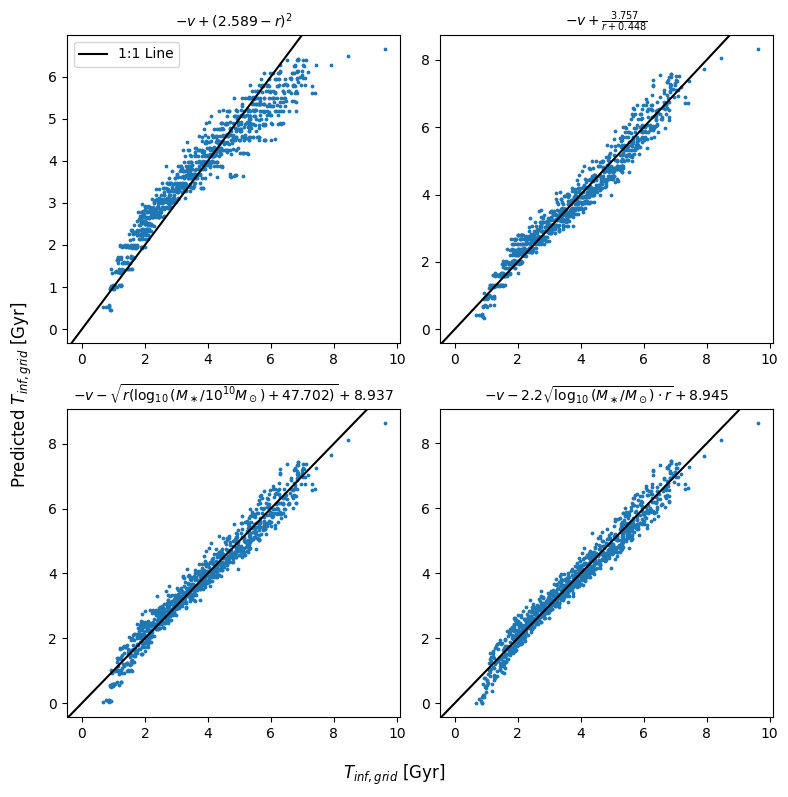

In [16]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8,8))
ax = axes.flatten()

for i in range(4):
    ax[i].axline((0, 0), slope=1, color='black', label='1:1 Line')

ax[0].scatter(y_mean[99], eqn1noM(X_binned[99].T), s=3)
ax[0].set_title(r"$-v + (2.589 - r)^2$", fontsize=10)
ax[0].legend()

ax[1].scatter(y_mean[99], eqn2noM(X_binned[99].T), s=3)
ax[1].set_title(r"$-v + \frac{3.757}{r + 0.448}$", fontsize=10)

ax[2].scatter(y_mean[99], eqn3(X_binned[99].T), s=3)
ax[2].set_title(r"$-v - \sqrt{r(\log_{10}(M_\ast/10^{10} M_\odot) + 47.702)} + 8.937$", fontsize=10)

ax[3].scatter(y_mean[99], eqn3_2(X_binned[99].T), s=3)
ax[3].set_title(r"$-v - 2.2\sqrt{\log_{10}(M_\ast/M_\odot) \cdot r} + 8.945$", fontsize=10)

fig.supxlabel(r"$T_{inf, grid}$ [Gyr]")
fig.supylabel(r"Predicted $T_{inf, grid}$ [Gyr]")

plt.tight_layout()


Test on only linear fitting

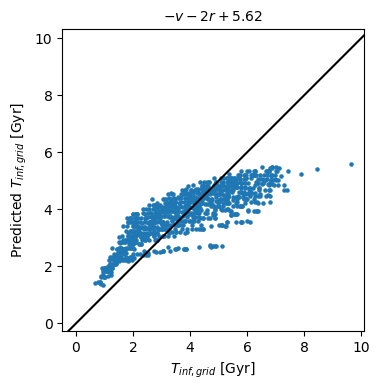

In [17]:
def test(Xvect): # from withMvir
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    return np.maximum(0,-v - (r + r) + 5.62)

plt.figure(figsize=(4.0,4.0))
plt.scatter(y_mean[99], test(X_binned[99].T), s=5)
plt.axline((0, 0), slope=1, color='black', label='1:1 Line')
# plt.xlim(0,8)
# plt.ylim(0,8)
plt.xlabel(r"$T_{inf,grid}$ [Gyr]")
plt.ylabel(r"Predicted $T_{inf,grid}$ [Gyr]")
plt.axis('square')
plt.title(r"$-v -2r + 5.62$", fontsize=10)
plt.tight_layout()

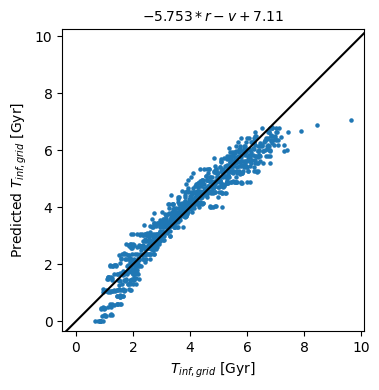

In [18]:
def test1(Xvect): # from withMvir
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    return np.maximum(0,-5.753*r - v + 7.11)

plt.figure(figsize=(4.0,4.0))
plt.scatter(y_mean[99], test1(X_binned[99].T), s=5)
plt.axline((0, 0), slope=1, color='black', label='1:1 Line')
# plt.xlim(0,8)
# plt.ylim(0,8)
plt.xlabel(r"$T_{inf,grid}$ [Gyr]")
plt.ylabel(r"Predicted $T_{inf,grid}$ [Gyr]")
plt.axis('square')
plt.title(r"$-5.753*r - v + 7.11$", fontsize=10)
plt.tight_layout()

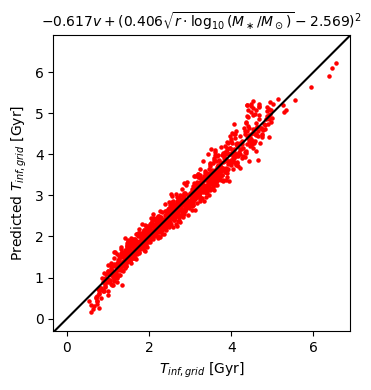

In [25]:
# test at snapshot
def test1(Xvect):
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    return np.maximum(0,-0.617*v + (0.406*np.sqrt(logms*r) - 2.569)**2)

plt.figure(figsize=(4.0,4.0))
plt.scatter(y_mean[78], test1(X_binned[78].T), s=5, color="red")
plt.axline((0, 0), slope=1, color='black', label='1:1 Line')
# plt.xlim(0,8)
# plt.ylim(0,8)
plt.xlabel(r"$T_{inf,grid}$ [Gyr]")
plt.ylabel(r"Predicted $T_{inf,grid}$ [Gyr]")
plt.axis('square')
plt.title(r"$-0.617v + (0.406\sqrt{r\cdot\log_{10}(M_\ast/M_\odot)} - 2.569)^2$", fontsize=10)
plt.tight_layout()

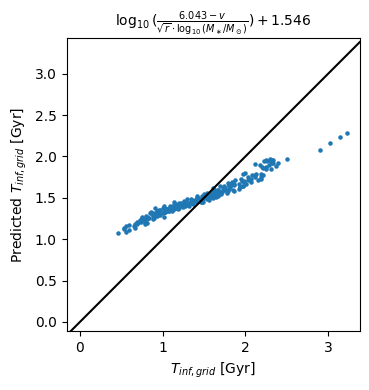

In [ ]:
def test2(Xvect):
    r = Xvect[0]
    v = Xvect[1]
    logms = Xvect[2]
    return np.maximum(0,np.log10((6.043 - v)/(logms*np.sqrt(r))) + 1.546)

plt.figure(figsize=(4.0,4.0))
plt.scatter(y_mean[50], test2(X_binned[50].T), s=5)
plt.axline((0, 0), slope=1, color='black', label='1:1 Line')
# plt.xlim(0,8)
# plt.ylim(0,8)
plt.xlabel(r"$T_{inf,grid}$ [Gyr]")
plt.ylabel(r"Predicted $T_{inf,grid}$ [Gyr]")
plt.axis('square')
plt.title(r"$\log_{10}(\frac{6.043 - v}{\sqrt{r}\cdot\log_{10}(M_\ast/M_\odot)}) + 1.546$", fontsize=10)
plt.tight_layout()

Extra Plots

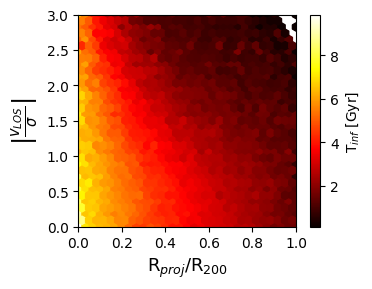

In [ ]:
plt.figure(figsize=(3.8,3.0))
plt.hexbin(r_axis[99], v_axis[99], C=infall_axis1[99], reduce_C_function=np.mean, gridsize=30, cmap='hot', extent=[0, 1, 0, 3])
plt.xlim(0,1)
plt.ylim(0,3)
plt.colorbar(label= 'T$_{inf}$ [Gyr]')
plt.xlabel('R$_{proj}$/R$_{200}$', fontsize = 13)
plt.ylabel(r'$\left| \frac{v_{LOS}}{\sigma} \right|$', fontsize= 15)
plt.tight_layout()